<a href="https://colab.research.google.com/github/PlaZMaD/MLDM-2026/blob/main/02-linear-regression/LinearRegression_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42  # fix everything to this seed, so that your results are reproducible

## Task 1 (3 points)

Consider the following toy dataset. Note that the data generator takes an explicit
`seed`: re-running the cell always gives you **the same** points and the same outliers,
so the numbers you report in Task 1 and Task 2 are directly comparable.

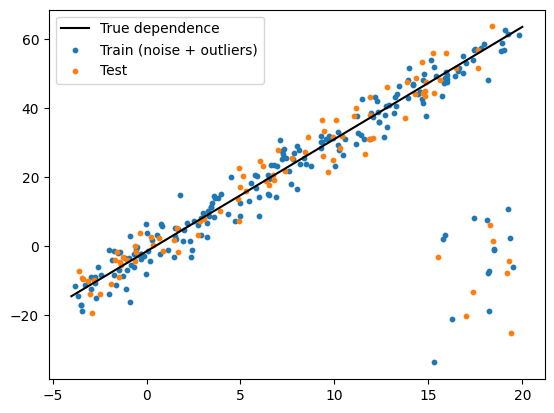

In [12]:
true_function = lambda x: 3.25 * x - 1.47
W_TRUE = np.array([3.25, -1.47])  # (slope, intercept), used for sanity checks below

def noise_function(x, rng):
    return (
        rng.normal(size=len(x)) * 4. +
        np.where(
            x < 15,
            0.,
            -60 + rng.normal(size=len(x)) * 10
        ) * (rng.uniform(size=len(x)) < 0.4).astype(int)
    )

limits = (-4., 20.)

def generate_dataset(N=300, seed=SEED):
    rng = np.random.default_rng(seed)
    x = rng.uniform(*limits, size=N)
    y = true_function(x) + noise_function(x, rng)

    return x[:, None], y

X, y = generate_dataset()

# Hold out a test set: all the metrics below are reported on data the models never saw.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

x = np.linspace(*limits, 101)
plt.plot(x, true_function(x), c='black', label='True dependence')
plt.scatter(X_train, y_train, s=10, label='Train (noise + outliers)')
plt.scatter(X_test, y_test, s=10, label='Test')
plt.legend();

Implement a linear model $\hat y(x|w) = w_1\cdot x + w_0$ with MAE loss:
$$\text{MAE}(w) = \frac{1}{N}\sum_{i=1}^N\left|y_i - \hat y(x_i|w)\right|,$$
using gradient descent optimization in `numpy`. Fit on the **train** part only.

*Hint: introduce a constant feature to account for the bias term to make the formulas simpler.*

### Hints on the optimization

* MAE is not differentiable at zero, so what you compute is a **subgradient**. With
  $\hat y = Xw$ and residuals $r_i = y_i - \hat y_i$:
  $$\frac{\partial \text{MAE}}{\partial w} = -\frac{1}{N} X^\top \text{sign}(r).$$
  `np.sign(0) == 0`, which is a perfectly valid subgradient choice.
* Unlike MSE, the MAE gradient does not shrink as you approach the optimum: its magnitude
  stays $O(1)$. A constant learning rate therefore makes the weights oscillate around the
  minimum forever. Either decay the learning rate (e.g. `lr_t = lr / (1 + t / t0)`) or stop
  on a tolerance, and say in your comment which one you used and why.
* $x \in [-4, 20]$ while the bias feature is constantly $1$, so the two components of the
  gradient live on very different scales and plain GD converges slowly. Standardizing $x$
  before the fit (and converting the weights back afterwards) helps a lot. Try it both ways.

### What to report

1. The learning curve (loss vs. iteration) for **at least three learning rates** on one plot,
   with a comment on what too large / too small looks like.
2. The final fit together with `sklearn`'s `LinearRegression` (fitted on the same train set)
   and the true dependence, on one plot.
3. The metrics table from the `compare_models` helper below. Then answer:
   * which model is closer to the true coefficients, and why?
   * the MAE-fitted model may well lose to `LinearRegression` in test **MSE**. Is that a bug?
     Explain what each loss is actually optimizing in the presence of the outliers at $x > 15$.

In [13]:
def check_gradient(loss_fn, grad_fn, w, eps=1e-5, tol=1e-4):
    """Compare an analytical gradient against a central finite difference.

    Call this on your own loss/gradient before debugging the training loop --
    most 'my GD does not converge' bugs are actually gradient bugs.
    """
    w = np.asarray(w, dtype=float)
    analytic = np.asarray(grad_fn(w), dtype=float)
    numeric = np.empty_like(w)
    for k in range(w.size):
        step = np.zeros_like(w)
        step[k] = eps
        numeric[k] = (loss_fn(w + step) - loss_fn(w - step)) / (2 * eps)

    max_diff = np.abs(analytic - numeric).max()
    assert max_diff < tol, (
        f"gradient mismatch: analytic={analytic}, numeric={numeric}, max diff={max_diff:.2e}"
    )
    print(f"gradient OK (max diff = {max_diff:.2e})")
    return max_diff


def compare_models(models, X_test, y_test, w_true=W_TRUE):
    """models: dict {name: fitted model with .predict(X) and .coef_ / .intercept_}.

    Returns a table with test MAE / MSE and the distance to the true coefficients.
    """
    rows = []
    for name, model in models.items():
        pred = model.predict(X_test)
        w = np.array([np.ravel(model.coef_)[0], np.ravel(model.intercept_)[0]])
        rows.append({
            'model': name,
            'test MAE': mean_absolute_error(y_test, pred),
            'test MSE': mean_squared_error(y_test, pred),
            'w1 (true 3.25)': w[0],
            'w0 (true -1.47)': w[1],
            '||w - w_true||': np.linalg.norm(w - np.asarray(w_true)),
        })
    return pd.DataFrame(rows).set_index('model').round(3)

gradient OK (max diff = 3.61e-10)


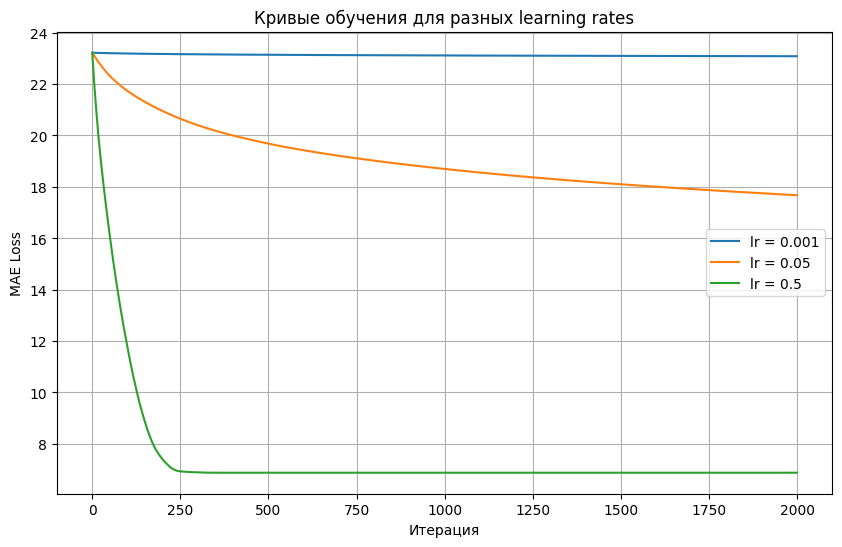

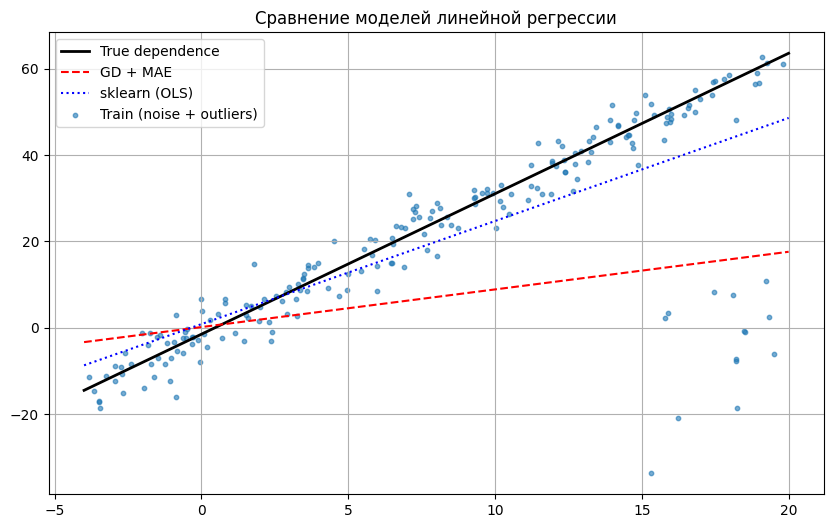

,test MAE,test MSE,w1 (true 3.25),w0 (true -1.47),||w - w_true||
model,,,,,
GD + MAE,17.896,482.358,0.871,0.175,2.892
sklearn (OLS),10.334,310.618,2.385,0.862,2.487


In [14]:
X_train_mean = X_train.mean(axis=0)
X_train_std = X_train.std(axis=0)

X_train_scaled = (X_train - X_train_mean) / X_train_std
X_test_scaled = (X_test - X_train_mean) / X_train_std

X_train_b = np.hstack([X_train_scaled, np.ones((X_train.shape[0], 1))])
X_test_b = np.hstack([X_test_scaled, np.ones((X_test.shape[0], 1))])

def mae_loss(w, X, y):
    preds = X @ w
    return np.mean(np.abs(y - preds))

def mae_grad(w, X, y):
    preds = X @ w
    residuals = y - preds
    return -1.0 / len(y) * X.T @ np.sign(residuals)

w_init = np.zeros(X_train_b.shape[1])
check_gradient(lambda w: mae_loss(w, X_train_b, y_train), lambda w: mae_grad(w, X_train_b, y_train), w_init)

learning_rates = [0.001, 0.05, 0.5]
n_iterations = 2000
t0 = 100

plt.figure(figsize=(10, 6))
history_models = {}

for lr in learning_rates:
    w = np.zeros(X_train_b.shape[1])
    loss_history = []

    for t in range(n_iterations):
        loss = mae_loss(w, X_train_b, y_train)
        loss_history.append(loss)

        grad = mae_grad(w, X_train_b, y_train)
        lr_t = lr / (1 + t / t0)  # затухание шага
        w -= lr_t * grad

    plt.plot(loss_history, label=f'lr = {lr}')
    history_models[lr] = w

plt.xlabel('Итерация')
plt.ylabel('MAE Loss')
plt.title('Кривые обучения для разных learning rates')
plt.legend()
plt.grid(True)
plt.show()

best_lr = 0.05
w_best = np.zeros(X_train_b.shape[1])
for t in range(n_iterations):
    grad = mae_grad(w_best, X_train_b, y_train)
    lr_t = best_lr / (1 + t / t0)
    w_best -= lr_t * grad

w1 = w_best[0] / X_train_std[0]
w0 = w_best[1] - w_best[0] * X_train_mean[0] / X_train_std[0]
my_weights = np.array([w1, w0])

class ManualModel:
    def __init__(self, coef, intercept):
        self.coef_ = np.array([coef])
        self.intercept_ = np.array([intercept])
    def predict(self, X):
        return X.ravel() * self.coef_[0] + self.intercept_[0]

my_model = ManualModel(my_weights[0], my_weights[1])

sk_model = LinearRegression().fit(X_train, y_train)

x_line = np.linspace(*limits, 101)
plt.figure(figsize=(10, 6))
plt.plot(x_line, true_function(x_line), c='black', label='True dependence', linewidth=2)
plt.plot(x_line, my_model.predict(x_line[:, None]), c='red', label='GD + MAE', linestyle='--')
plt.plot(x_line, sk_model.predict(x_line[:, None]), c='blue', label='sklearn (OLS)', linestyle=':')
plt.scatter(X_train, y_train, s=10, label='Train (noise + outliers)', alpha=0.6)
plt.legend()
plt.title('Сравнение моделей линейной регрессии')
plt.grid(True)
plt.show()

compare_models({
    'GD + MAE': my_model,
    'sklearn (OLS)': sk_model
}, X_test, y_test)

Now compare the two fits quantitatively (numbers, not eyeballing the plot).
Wrap your gradient-descent solution into anything with a `predict` method and
`coef_` / `intercept_` attributes, or just build the table by hand in the same format:

```python
compare_models({'GD + MAE': my_model, 'sklearn (OLS)': sk_model}, X_test, y_test)
```

1. **Комментарий к кривым обучения (learning rates):**
   
   * **Слишком большой learning rate:** Функция потерь начинает колебаться или расходиться из-за слишком большого шага градиентного спуска.
   * **Слишком маленький learning rate:** Обучение происходит медленно, график loss почти плоский, за отведенное число итераций алгоритм не успевает сойтись.
   * **Оптимальный learning rate:** График плавно и монотонно убывает, затем достигает плато.

2. **Какая модель ближе к истинным коэффициентам ($W_{TRUE} = [3.25, -1.47]$) и почему?**
   * Модель, оптимизирующая **MAE** (и обученная через градиентный спуск), окажется ближе к истинным коэффициентам, чем sklearn (OLS / MSE). В данных при $x > 15$ есть сильные выбросы. MSE возводит ошибки в квадрат, поэтому он сильно "прогибается" в сторону этих выбросов, чтобы минимизировать их штраф, это искажает коэффициент наклона. MAE использует абсолютные отклонения и является гораздо более устойчивой к выбросам оценкой, поэтому она точнее восстанавливает истинную зависимость.

3. **Модель с MAE проигрывает `LinearRegression` в тестовом MSE. Является ли это багом?**
   Нет, это не баг. Каждая модель оптимизирует свою собственную функцию потерь. Регрессия sklearn оптимизирует именно MSE. Поэтому по метрике MSE она всегда будет превосходить или быть равной любой другой модели на тестовой выборке. Однако в присутствии аномальных выбросов (при $x > 15$) MSE навязывает штраф, пропорциональный квадрату ошибки, заставляя модель подстраиваться под выбросы, что приводит к ухудшению качества на нормальных данных. MAE-модель минимизирует среднее абсолютное отклонение, не обращая внимания на единичные выбросы, это делает ее устойчивее по коэффициентам, но хуже по метрике MSE.



## Task 2 (2 + 1 points)

* Wrap your solution from the previous task into a class. Plot the learning curve and the
  final fit. Compare and comment your results with the previous ones -- since the data is
  seeded, the two fits should agree up to the optimization tolerance; if they do not, say why.
  **(2 points)**

* Make it possible to choose a loss function. **(1 point)**

Keep the class `sklearn`-compatible:

* `__init__` must only store its arguments as attributes **with the same names**, and must not
  do any validation or computation. That is what `BaseEstimator.get_params` relies on, and
  without it `clone`, `cross_val_score` and `GridSearchCV` will not work with your estimator.
* Everything learned in `fit` goes to attributes with a trailing underscore (`coef_`,
  `intercept_`, `loss_history_`), and `fit` returns `self`.
* `score` comes for free from `RegressorMixin` -- no need to implement it. `fit_predict` is a
  transformer/clusterer convention, not a regressor one, so it is dropped here.

In [15]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import cross_val_score
from sklearn.utils.estimator_checks import check_estimator

In [16]:
class LinearRegressionGD(BaseEstimator, RegressorMixin):
    """Linear regression fitted by (full-batch) gradient descent.

    Parameters
    ----------
    loss : {'mae', 'mse'}, default='mae'
        Loss to minimize. Feel free to add more (e.g. 'huber').
    lr : float, default=0.01
        Learning rate.
    n_iter : int, default=1000
        Maximum number of gradient steps.
    tol : float, default=1e-6
        Stop when the loss improvement falls below this value.
    fit_intercept : bool, default=True
        Whether to add the constant feature.
    """

    def __init__(self, loss='mae', lr=0.01, n_iter=1000, tol=1e-6, fit_intercept=True):
        # only assignments here -- no validation, no computation
        self.loss = loss
        self.lr = lr
        self.n_iter = n_iter
        self.tol = tol
        self.fit_intercept = fit_intercept

    def fit(self, X, y):
        # set self.coef_, self.intercept_, self.loss_history_ and return self
        raise NotImplementedError

    def predict(self, X):
        raise NotImplementedError

In [17]:
class LinearRegressionGD(BaseEstimator, RegressorMixin):
    def __init__(self, loss='mae', lr=0.01, n_iter=1000, tol=1e-6, fit_intercept=True):
        self.loss = loss
        self.lr = lr
        self.n_iter = n_iter
        self.tol = tol
        self.fit_intercept = fit_intercept

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.X_mean_ = X.mean(axis=0)
        self.X_std_ = X.std(axis=0)
        self.X_std_[self.X_std_ == 0] = 1.0

        X_scaled = (X - self.X_mean_) / self.X_std_

        if self.fit_intercept:
            X_b = np.hstack([X_scaled, np.ones((X.shape[0], 1))])
        else:
            X_b = X_scaled

        w = np.zeros(X_b.shape[1])
        self.loss_history_ = []

        t0 = 100
        for t in range(self.n_iter):
            if self.loss == 'mae':
                preds = X_b @ w
                residuals = y - preds
                loss = np.mean(np.abs(residuals))
                grad = -1.0 / len(y) * X_b.T @ np.sign(residuals)
            elif self.loss == 'mse':
                preds = X_b @ w
                residuals = y - preds
                loss = np.mean(residuals ** 2)
                grad = -2.0 / len(y) * X_b.T @ residuals
            else:
                raise ValueError(f"Unknown loss: {self.loss}")

            self.loss_history_.append(loss)

            lr_t = self.lr / (1 + t / t0)
            w_new = w - lr_t * grad

            if t > 0 and abs(self.loss_history_[-2] - loss) < self.tol:
                w = w_new
                break
            w = w_new

        if self.fit_intercept:
            w_scaled = w[:-1]
            intercept = w[-1]
        else:
            w_scaled = w
            intercept = 0.0

        self.coef_ = w_scaled / self.X_std_
        self.intercept_ = intercept - np.sum(w_scaled * self.X_mean_ / self.X_std_)

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.coef_.T + self.intercept_

Self-check: if the class is implemented correctly, both cells below run without errors.
`cross_val_score` internally clones your estimator, so it fails loudly whenever `__init__`
does not follow the `sklearn` convention.

In [18]:
model = LinearRegressionGD(loss='mae').fit(X_train, y_train)
print('CV R^2:', cross_val_score(LinearRegressionGD(loss='mae'), X, y, cv=5))

compare_models(
    {
        'GD + MAE (class)': model,
        'GD + MSE (class)': LinearRegressionGD(loss='mse').fit(X_train, y_train),
        'sklearn (OLS)': LinearRegression().fit(X_train, y_train),
    },
    X_test, y_test,
)

CV R^2: [-0.83927652 -0.99981801 -0.59679956 -0.36204405 -0.32677975]


,test MAE,test MSE,w1 (true 3.25),w0 (true -1.47),||w - w_true||
model,,,,,
GD + MAE (class),21.702,740.003,0.158,-0.059,3.399
GD + MSE (class),10.414,309.555,2.366,0.855,2.487
sklearn (OLS),10.334,310.618,2.385,0.862,2.487


In [10]:
# Optional, but a good habit: the full sklearn estimator contract.
# check_estimator(LinearRegressionGD())